# Objective Functions

\begin{equation}
    F_1=\max \sum_{i=1}^{|I|} (\alpha_B Bio_i + \beta_B \tilde{E_i}) \cdot x_i
\end{equation}

\begin{equation}
    F_2 = \max \sum_{i \in I} \tilde{Car}_i \cdot x_i
\end{equation}

\begin{equation}
    F_3 = \max \sum_{i \in I} \tilde{U}_i \cdot x_i
\end{equation}

\begin{equation}
    F_4 = \min \sum_{i \in I} \tilde{Rev}_i \cdot x_i
\end{equation}

\begin{equation}
    F_5 = \min \phi
\end{equation}

# Constraints

\begin{equation}
    \sum_{i\in I}c_i\cdot x_i\leq B
\end{equation}

\begin{equation}
    x_i\leq A_i\cdot y_i\quad \forall i\in I
\end{equation}

\begin{equation}
  x_i\geq m\cdot y_i  \quad \forall i \in I
\end{equation}

\begin{equation}
    c_i \cdot x_i \leq \theta \cdot B \quad \forall i \in I
\end{equation}

\begin{equation}
   \sum_{i\in I}x_i\leq K 
\end{equation}

\begin{equation}
   \sum_{i\in I}y_i\geq \varepsilon M 
\end{equation}

\begin{equation}
    \sum_{i \in I_{arc}} c_i \cdot x_i \ge 12,350,000
\end{equation}

\begin{equation}
    \phi\geq \sum_{i = 1}^{|I|-1} \sum_{j=i+1}^{|I|} \frac{z_{i, j}}{d_{i, j}}
\end{equation}

\begin{equation}
    \phi \geq 0
\end{equation}

\begin{equation}
    z_{i, j} \geq y_i + y_j -1 \quad \forall i < j
\end{equation}

\begin{equation}
    z_{i, j} \leq y_i, \quad z_{i, j} \leq y_j \quad \forall i <j
\end{equation}

\begin{equation}
    F_j\geq F_j^*\quad j=1,2,3\quad (\text{applied sequentially when solving }F_{j+1})
\end{equation}

\begin{equation}
    x_i\geq0,\quad y_i\in \{0,1\}\quad **z_{i, j} \in \{0, 1\} \quad \forall i \in I \quad **\forall j \in J
\end{equation}


# Plan for Budget Sensitivity Analysis
Idea is to have 3 budget scenarios
1. High budget
2. Medium budget
3. Low budget

- Aim is to see how the main objective function scores change as a result

In [1]:
from math import floor

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pulp

# load the data
df = pd.read_csv("Data\\MPAA_model_data.csv")

df['carbon index norm'] = df['carbon index norm'].fillna(df['carbon index norm'].mean())

# List of municipalities IDs
municipalities = df['NM_MUN'].tolist()

# Biodiversity score for each municipality Bio_i
Bio = df.set_index('NM_MUN')['biodiversity_priority_index'].to_dict()

# Extinction risk normalised E_hat_i
E_hat = df.set_index('NM_MUN')['Extinction risk score norm'].to_dict()

# Carbon sequestration potential for each municipality Car_hat_i
Car_hat = df.set_index('NM_MUN')['carbon index norm'].to_dict()

# Land available for planting in each municipality A_i
A = df.set_index('NM_MUN')['eligible_area_ha_mapbiomas'].to_dict()

# Urgency score U_hat_i
U_hat = df.set_index('NM_MUN')['urgency_5yr_index'].to_dict()

# Reversal risk Rev_hat_i
Rev_hat = df.set_index('NM_MUN')['reversal_risk'].to_dict()

# cost per hectare for each municipality c_i
c = df.set_index('NM_MUN')['cost_per_ha'].to_dict()

# max cost per hectare across all municipalities (for cost-effectiveness)
c_max = max(c.values())
c_max

# ========================= Fixed Additional Parameters ======================== 
B = 489850000  # Total budget in dollars
m = 200    # Minimum viable project scale in hectares
K = 560000 # Updated based on new data and assumptions - can implement up to 560,000 hectares per year across all municipalities
N_min = 25       # Minimum number of municipalities to fund (Fairness constraint)
theta = 0.20  # No municipality can receive more than 20% of the total budget B

# weight constraints
alpha_B = 0.5      # Weight for Biodiversity
beta_B = 0.5       # Weight for Extinction Risk


In [2]:
arc_municipalities = [
    "Abaetetuba",
    "Abel Figueiredo",
    "Acará",
    "Ananindeua",
    "Aurora do Pará",
    "Bagre",
    "Baião",
    "Barcarena",
    "Belém",
    "Benevides",
    "Bom Jesus do Tocantins",
    "Brejo Grande do Araguaia",
    "Breu Branco",
    "Bujaru",
    "Cametá",
    "Canaã dos Carajás",
    "Conceição do Araguaia",
    "Concórdia do Pará",
    "Curionópolis",
    "Eldorado do Carajás",
    "Floresta do Araguaia",
    "Goianésia do Pará",
    "Igarapé-Miri",
    "Inhangapi",
    "Irituia",
    "Itupiranga",
    "Jacundá",
    "Limoeiro do Ajuru",
    "Mãe do Rio",
    "Marituba",
    "Mocajuba",
    "Moju",
    "Nova Ipixuna",
    "Oeiras do Pará",
    "Palestina do Pará",
    "Piçarra",
    "Salvaterra",
    "Santa Bárbara do Pará",
    "Santa Izabel do Pará",
    "São Domingos do Araguaia",
    "São Domingos do Capim",
    "São Geraldo do Araguaia",
    "São João do Araguaia",
    "Sapucaia",
    "Tailândia",
    "Tomé-Açu",
    "Tucuruí",
    "Xinguara",
    "Água Azul do Norte",
    "Anajás",
    "Anapu",
    "Bannach",
    "Bonito",
    "Breves",
    "Cachoeira do Arari",
    "Castanhal",
    "Chaves",
    "Colares",
    "Cumaru do Norte",
    "Curralinho",
    "Gurupá",
    "Marabá",
    "Melgaço",
    "Muaná",
    "Novo Repartimento",
    "Ourém",
    "Ourilândia do Norte",
    "Pacajá",
    "Parauapebas",
    "Pau D'Arco",
    "Ponta de Pedras",
    "Portel",
    "Porto de Moz",
    "Redenção",
    "Rio Maria",
    "Santa Cruz do Arari",
    "Santa Luzia do Pará",
    "Santa Maria das Barreiras",
    "Santana do Araguaia",
    "Santo Antônio do Tauá",
    "São Caetano de Odivelas",
    "São Félix do Xingu",
    "São Francisco do Pará",
    "São Miguel do Guamá",
    "São Sebastião da Boa Vista",
    "Senador José Porfírio",
    "Soure",
    "Vigia",
    "Capitão Poço",
    "Dom Eliseu",
    "Garrafão do Norte",
    "Ipixuna do Pará",
    "Nova Esperança do Piriá",
    "Paragominas",
    "Rondon do Pará",
    "Ulianópolis",
    "Viseu"]

In [3]:
dist_df = pd.read_csv("Data\\distance_matrix_named.csv", index_col=0)

# --- 1. SPATIAL PRE-COMPUTATION ---
D_max = 250.0
valid_pairs = []
inv_dist = {}

# Ensure IDs are strings to prevent lookup errors
mun_ids = [str(m) for m in municipalities]
dist_df.index = dist_df.index.astype(str)
dist_df.columns = dist_df.columns.astype(str)

for i in mun_ids:
    for j in mun_ids:
        if i < j: # Ensures we only check each unique pair once
            try:
                dij = float(dist_df.at[i, j])
                if 0 < dij <= D_max:
                    valid_pairs.append((i, j))
                    inv_dist[(i, j)] = 1.0 / dij
            except Exception:
                continue

print(f"Generated {len(valid_pairs)} valid spatial pairs within {D_max}km threshold.")

Generated 2850 valid spatial pairs within 250.0km threshold.


In [4]:
import geopandas as gpd
municipalities_gdf = gpd.read_file("Data\\BR_Municipios_2024.shp")

# Filter Pará and project to metric CRS (meters
para_gdf = municipalities_gdf[municipalities_gdf["NM_UF"] == "Pará"].copy()
    
len(para_gdf)

144

## Base Model

In [5]:
# --- 2. BASE MODEL CREATION FUNCTION ---
def create_base_model(sense=pulp.LpMaximize):
    model = pulp.LpProblem("PMV_Hierarchical_Model", sense)

    # ==========================================
    # 1. Decision Variables
    # ==========================================
    x = pulp.LpVariable.dicts("x", mun_ids, lowBound=0, cat=pulp.LpContinuous)
    
    y = pulp.LpVariable.dicts("y", mun_ids, cat=pulp.LpBinary)
    
    z = pulp.LpVariable.dicts("z", valid_pairs, lowBound=0, upBound=1, cat=pulp.LpContinuous)

    # ==========================================
    # 2. Core Constraints
    # ==========================================
    # Budget and Capacity Limits
    model += pulp.lpSum(c[i] * x[i] for i in mun_ids) <= B, "Budget_Limit"
    model += pulp.lpSum(x[i] for i in mun_ids) <= K, "Global_Capacity_Limit"
    
    # Geographic Equity Threshold
    model += pulp.lpSum(y[i] for i in mun_ids) >= N_min, "Min_Municipalities"

    # Arc of Deforestation Ring-fenced Minimum
    valid_arc_muns = [i for i in arc_municipalities if str(i) in c]
    model += pulp.lpSum(c[str(i)] * x[str(i)] for i in valid_arc_muns) >= 12350000, "Arc_Minimum"

    # ==========================================
    # 3. Logical Bounds
    # ==========================================
    for i in mun_ids:
        # Cannot restore more than eligible area
        model += x[i] <= A[i] * y[i], f"Upper_Bound_Area_{i}"
        
        # Must meet minimum viable scale if selected
        model += x[i] >= m * y[i], f"Min_Viable_Scale_{i}"

        # No municipality can receive more than theta share of total budget
        model += c[i] * x[i] <= theta * B, f"Max_Budget_Share_{i}"

    # ==========================================
    # 4. Fortet–Glover Linearisation for z_ij
    # ==========================================
    for (i, j) in valid_pairs:
        model += z[(i, j)] <= y[i], f"FG_Upper_i_{i}_{j}"
        model += z[(i, j)] <= y[j], f"FG_Upper_j_{i}_{j}"
        
        # This forces z up to 1 when both y[i] and y[j] are 1
        model += z[(i, j)] >= y[i] + y[j] - 1, f"FG_Lower_{i}_{j}"

    # ==========================================
    # 5. Objective Expressions
    # ==========================================
    # Storing these as lpSum expressions rather than variables saves matrix rows in Gurobi
    obj_bio = pulp.lpSum((alpha_B * Bio[i] + beta_B * E_hat[i]) * x[i] for i in mun_ids)
    obj_urg = pulp.lpSum(U_hat[i] * x[i] for i in mun_ids)
    obj_car = pulp.lpSum(Car_hat[i] * x[i] for i in mun_ids)
    obj_rev = pulp.lpSum(Rev_hat[i] * x[i] for i in mun_ids)
    
    # Spatial penalty is only calculated for pairs within D_max
    obj_spatial = pulp.lpSum(z[(i, j)] * inv_dist[(i, j)] for (i, j) in valid_pairs)

    return model, x, y, obj_bio, obj_urg, obj_car, obj_rev, obj_spatial

## Nadir Utopia Tolerances

In [6]:
tolerances = pd.read_csv("Outputs\\lexicographic_tolerances.csv")

# Assuming you have your utopia_nadir_values DataFrame loaded, extract the ranges:
range_bio = tolerances.loc[tolerances['Objective'] == 'Bio_and_extinction', 'range'].values[0]
range_car = tolerances.loc[tolerances['Objective'] == 'Carbon', 'range'].values[0]
range_urg = tolerances.loc[tolerances['Objective'] == 'Urgency', 'range'].values[0]
range_rev = tolerances.loc[tolerances['Objective'] == 'Reversal Risk', 'range'].values[0]


print(range_bio, range_car, range_urg, range_rev)

144961.85141067387 188096.17648078152 141952.72071175126 216855.2722493316


In [7]:
# ========================== Budget Sensitivity Analysis ==========================

# Define budgets as a list of (label, value) tuples
budgets = [
    ("low",    221_370_000), # Low budget scenario 
    ("medium", 489_850_000), # Original budget scenario
    ("high",   790_000_000) # High budget scenario
]

# ── Storage for results across all budget runs ──────────────────────────────────
results_allocation = {}   # label -> DataFrame of selected municipalities
results_objectives = {}   # label -> dict of objective/step values

# ══════════════════════════════════════════════════════════════════════════════
# MAIN BUDGET LOOP
# ══════════════════════════════════════════════════════════════════════════════
for budget_label, B in budgets:

    print("\n" + "=" * 70)
    print(f"  BUDGET SCENARIO: {budget_label.upper()}  |  B = R$ {B:,.2f}")
    print("=" * 70)

    # ── Tolerance Parameters ────────────────────────────────────────────────
    alpha = 0.05

    range_bio = tolerances.loc[tolerances['Objective'] == 'Bio_and_extinction', 'range'].values[0]
    range_car = tolerances.loc[tolerances['Objective'] == 'Carbon',             'range'].values[0]
    range_urg = tolerances.loc[tolerances['Objective'] == 'Urgency',            'range'].values[0]
    range_rev = tolerances.loc[tolerances['Objective'] == 'Reversal Risk',      'range'].values[0]

    tol_bio = alpha * range_bio
    tol_car = alpha * range_car
    tol_urg = alpha * range_urg
    tol_rev = alpha * range_rev

    print(f"\nTolerances (alpha={alpha}): Bio={tol_bio:.2f} | Car={tol_car:.2f} | Urg={tol_urg:.2f} | Rev={tol_rev:.2f}")

    # ── Step 1: Maximize Biodiversity & Threat (F1) ─────────────────────────
    print("\nStep 1: Biodiversity & Threat...")
    model, x, y, obj_bio, obj_urg, obj_car, obj_rev, obj_spatial = create_base_model(pulp.LpMaximize)
    model += obj_bio, "Objective_F1"
    model.solve(pulp.GUROBI(msg=False))
    if pulp.LpStatus[model.status] != "Optimal":
        raise RuntimeError(f"[{budget_label}] Step 1 failed: {pulp.LpStatus[model.status]}")
    z1_star = pulp.value(model.objective)
    print(f"  F1* = {z1_star:.2f}  |  floor = {z1_star - tol_bio:.2f}")

    # ── Step 2: Maximize Carbon (F2) ────────────────────────────────────────
    print("\nStep 2: Carbon Sequestration...")
    model, x, y, obj_bio, obj_urg, obj_car, obj_rev, obj_spatial = create_base_model(pulp.LpMaximize)
    model += obj_bio >= z1_star - tol_bio, "Preserve_F1"
    model += obj_car, "Objective_F2"
    model.solve(pulp.GUROBI(msg=False))
    if pulp.LpStatus[model.status] != "Optimal":
        raise RuntimeError(f"[{budget_label}] Step 2 failed: {pulp.LpStatus[model.status]}")
    z2_star = pulp.value(model.objective)
    print(f"  F2* = {z2_star:.2f}  |  floor = {z2_star - tol_car:.2f}")

    # ── Step 3: Maximize Urgency (F3) ───────────────────────────────────────
    print("\nStep 3: Urgency...")
    model, x, y, obj_bio, obj_urg, obj_car, obj_rev, obj_spatial = create_base_model(pulp.LpMaximize)
    model += obj_bio >= z1_star - tol_bio, "Preserve_F1"
    model += obj_car >= z2_star - tol_car, "Preserve_F2"
    model += obj_urg, "Objective_F3"
    model.solve(pulp.GUROBI(msg=False))
    if pulp.LpStatus[model.status] != "Optimal":
        raise RuntimeError(f"[{budget_label}] Step 3 failed: {pulp.LpStatus[model.status]}")
    z3_star = pulp.value(model.objective)
    print(f"  F3* = {z3_star:.2f}  |  floor = {z3_star - tol_urg:.2f}")

    # ── Step 4: Minimize Reversal Risk (F4) ─────────────────────────────────
    print("\nStep 4: Reversal Risk...")
    model, x, y, obj_bio, obj_urg, obj_car, obj_rev, obj_spatial = create_base_model(pulp.LpMinimize)
    model += obj_bio >= z1_star - tol_bio, "Preserve_F1"
    model += obj_car >= z2_star - tol_car, "Preserve_F2"
    model += obj_urg >= z3_star - tol_urg, "Preserve_F3"
    model += obj_rev, "Objective_F4"
    model.solve(pulp.GUROBI(msg=False))
    if pulp.LpStatus[model.status] != "Optimal":
        raise RuntimeError(f"[{budget_label}] Step 4 failed: {pulp.LpStatus[model.status]}")
    z4_star = pulp.value(model.objective)
    print(f"  F4* = {z4_star:.2f}  |  ceiling = {z4_star + tol_rev:.2f}")

    # ── Step 5: Minimize Spatial Dispersion (F5) ────────────────────────────
    print("\nStep 5: Spatial Dispersion...")
    model, x, y, obj_bio, obj_urg, obj_car, obj_rev, obj_spatial = create_base_model(pulp.LpMinimize)
    model += obj_bio >= z1_star - tol_bio, "Preserve_F1"
    model += obj_car >= z2_star - tol_car, "Preserve_F2"
    model += obj_urg >= z3_star - tol_urg, "Preserve_F3"
    model += obj_rev <= z4_star + tol_rev,  "Preserve_F4"
    model += obj_spatial, "Objective_F5"
    model.solve(pulp.GUROBI(msg=True, MIPGap=0.08, TimeLimit=3600))
    if pulp.LpStatus[model.status] != "Optimal":
        raise RuntimeError(f"[{budget_label}] Step 5 failed: {pulp.LpStatus[model.status]}")
    z5_star = pulp.value(model.objective)
    print(f"  F5* = {z5_star:.4f}")

    # ── Extract Allocation Results ───────────────────────────────────────────
    selected = []
    for i in municipalities:
        if y[i].varValue is not None and y[i].varValue > 0.5:
            area       = x[i].varValue
            cost       = c[i] * area
            selected.append({"Municipality": i, "Area_ha": round(area, 2), "Cost": round(cost, 2)})

    alloc_df = pd.DataFrame(selected)

    # ── Capture all objective values (needed by the analysis script) ─────────
    actual_bio     = pulp.value(obj_bio)
    actual_car     = pulp.value(obj_car)
    actual_urg     = pulp.value(obj_urg)
    actual_rev     = pulp.value(obj_rev)
    actual_spatial = pulp.value(obj_spatial)

    obj_df = pd.DataFrame([{
        "Budget_Label"  : budget_label,
        "Budget_BRL"    : B,
        "z1_star_bio"   : z1_star,
        "z2_star_car"   : z2_star,
        "z3_star_urg"   : z3_star,
        "z4_star_rev"   : z4_star,
        "z5_star_spatial": z5_star,
        "actual_bio"    : actual_bio,
        "actual_car"    : actual_car,
        "actual_urg"    : actual_urg,
        "actual_rev"    : actual_rev,
        "actual_spatial": actual_spatial,
        "alpha"         : alpha,
        "tol_bio"       : tol_bio,
        "tol_car"       : tol_car,
        "tol_urg"       : tol_urg,
        "tol_rev"       : tol_rev,
        "bio_lb"        : z1_star - tol_bio,
        "car_lb"        : z2_star - tol_car,
        "urg_lb"        : z3_star - tol_urg,
        "rev_ub"        : z4_star + tol_rev,
    }])

    # ── Store under label ────────────────────────────────────────────────────
    results_allocation[budget_label] = alloc_df
    results_objectives[budget_label] = obj_df

    print(f"\n  [{budget_label.upper()}] Done — {len(alloc_df)} municipalities selected, "
          f"R$ {alloc_df['Cost'].sum():,.0f} spent.")


# ══════════════════════════════════════════════════════════════════════════════
# UNPACK INTO NAMED DATAFRAMES 
# ══════════════════════════════════════════════════════════════════════════════
selected_df_budget_low    = results_allocation.get("low",    pd.DataFrame())
selected_df_budget_medium = results_allocation.get("medium", pd.DataFrame())
selected_df_budget_high   = results_allocation.get("high",   pd.DataFrame())

objectives_df_budget_low    = results_objectives.get("low",    pd.DataFrame())
objectives_df_budget_medium = results_objectives.get("medium", pd.DataFrame())
objectives_df_budget_high   = results_objectives.get("high",   pd.DataFrame())

# Handy combined view across all scenarios
all_objectives_df = pd.concat(results_objectives.values(), ignore_index=True)

print("\n✓ All budget scenarios complete.")
print(all_objectives_df[[
    "Budget_Label", "Budget_BRL",
    "actual_bio", "actual_car", "actual_urg", "actual_rev", "actual_spatial"
]].to_string(index=False))


  BUDGET SCENARIO: LOW  |  B = R$ 221,370,000.00

Tolerances (alpha=0.05): Bio=7248.09 | Car=9404.81 | Urg=7097.64 | Rev=10842.76

Step 1: Biodiversity & Threat...
Set parameter Username
Set parameter LicenseID to value 2793250
Academic license - for non-commercial use only - expires 2027-03-16
  F1* = 66769.25  |  floor = 59521.15

Step 2: Carbon Sequestration...
  F2* = 68340.24  |  floor = 58935.43

Step 3: Urgency...
  F3* = 47462.87  |  floor = 40365.23

Step 4: Reversal Risk...
  F4* = 45069.78  |  ceiling = 55912.54

Step 5: Spatial Dispersion...
Set parameter MIPGap to value 0.08
Set parameter TimeLimit to value 3600
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 12th Gen Intel(R) Core(TM) i5-1235U, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
TimeLimit  3600
MIPGap  0.08

Optimize a model with 8990 rows, 3138 columns and 21686 nonzeros (Mi

In [8]:
# sum cost column
print(selected_df_budget_low['Cost'].sum())
objectives_df_budget_low[["actual_bio", "actual_car", "actual_urg", "actual_rev", "actual_spatial"]]

221370000.01


,actual_bio,actual_car,actual_urg,actual_rev,actual_spatial
0,59521.152834,58935.426275,40365.232063,49190.947321,0.152677


In [9]:
print(selected_df_budget_medium['Cost'].sum())
objectives_df_budget_medium[["actual_bio", "actual_car", "actual_urg", "actual_rev", "actual_spatial"]]

489849999.99


,actual_bio,actual_car,actual_urg,actual_rev,actual_spatial
0,140747.230929,127860.738416,90556.793461,127082.924647,0.108272


In [10]:
print(selected_df_budget_high['Cost'].sum())
objectives_df_budget_high[["actual_bio", "actual_car", "actual_urg", "actual_rev", "actual_spatial"]]

789999999.9999999


,actual_bio,actual_car,actual_urg,actual_rev,actual_spatial
0,226264.652275,198845.706237,154936.782356,212584.560125,0.112536


In [11]:
objectives_df_budget_high_for_joint_table = objectives_df_budget_high[["actual_bio", "actual_car", "actual_urg", "actual_rev", "actual_spatial"]].copy()
objectives_df_budget_medium_for_joint_table = objectives_df_budget_medium[["actual_bio", "actual_car", "actual_urg", "actual_rev", "actual_spatial"]].copy()
objectives_df_budget_low_for_joint_table = objectives_df_budget_low[["actual_bio", "actual_car", "actual_urg", "actual_rev", "actual_spatial"]].copy()

# transpose then with header being the budget scenario and index being the objective
objectives_df_budget_high_for_joint_table = objectives_df_budget_high_for_joint_table.transpose()
objectives_df_budget_medium_for_joint_table = objectives_df_budget_medium_for_joint_table.transpose()
objectives_df_budget_low_for_joint_table = objectives_df_budget_low_for_joint_table.transpose()
objectives_df_budget_high_for_joint_table.columns = ["High Budget"]
objectives_df_budget_medium_for_joint_table.columns = ["Medium Budget"]
objectives_df_budget_low_for_joint_table.columns = ["Low Budget"]


# rename the indices to F1: Bio & Threat (Max), F2: Carbon (Max), F3: Urgency (Max), F4: Reversal Risk (Min), F5: Spatial (Min)
objectives_df_budget_high_for_joint_table.index = ["F1: Bio & Threat (Max)", "F2: Carbon (Max)", "F3: Urgency (Max)", "F4: Reversal Risk (Min)", "F5: Spatial Score (Min)"]
objectives_df_budget_medium_for_joint_table.index = ["F1: Bio & Threat (Max)", "F2: Carbon (Max)", "F3: Urgency (Max)", "F4: Reversal Risk (Min)", "F5: Spatial Score (Min)"]
objectives_df_budget_low_for_joint_table.index = ["F1: Bio & Threat (Max)", "F2: Carbon (Max)", "F3: Urgency (Max)", "F4: Reversal Risk (Min)", "F5: Spatial Score (Min)"]

joint_objectives_df = pd.concat([
    objectives_df_budget_low_for_joint_table,
    objectives_df_budget_medium_for_joint_table,
    objectives_df_budget_high_for_joint_table
], axis=1)

joint_objectives_df

,Low Budget,Medium Budget,High Budget
F1: Bio & Threat (Max),59521.152834,140747.230929,226264.652275
F2: Carbon (Max),58935.426275,127860.738416,198845.706237
F3: Urgency (Max),40365.232063,90556.793461,154936.782356
F4: Reversal Risk (Min),49190.947321,127082.924647,212584.560125
F5: Spatial Score (Min),0.152677,0.108272,0.112536


In [12]:
# average cost allocated to municipalities in each budget scenario
print("Average cost for Low Budget scenario:")
print(selected_df_budget_low['Cost'].mean())
average_cost_low = selected_df_budget_low['Cost'].mean()
print("Average cost for Medium Budget scenario:")
print(selected_df_budget_medium['Cost'].mean())
average_cost_medium = selected_df_budget_medium['Cost'].mean()
print("Average cost for High Budget scenario:")
print(selected_df_budget_high['Cost'].mean())
average_cost_high = selected_df_budget_high['Cost'].mean()

Average cost for Low Budget scenario:
8854800.0004
Average cost for Medium Budget scenario:
19593999.9996
Average cost for High Budget scenario:
31599999.999999996


In [13]:
# number of municipalities selected in each budget scenario
num_municipalities_low = len(selected_df_budget_low)
num_municipalities_medium = len(selected_df_budget_medium)
num_municipalities_high = len(selected_df_budget_high)
print(f"Number of municipalities selected in Low Budget scenario: {num_municipalities_low}")
print(f"Number of municipalities selected in Medium Budget scenario: {num_municipalities_medium}")
print(f"Number of municipalities selected in High Budget scenario: {num_municipalities_high}")

Number of municipalities selected in Low Budget scenario: 25
Number of municipalities selected in Medium Budget scenario: 25
Number of municipalities selected in High Budget scenario: 25


In [43]:
# average cost per hectare across selected municipalities in each budget scenario
selected_df_budget_low['Cost_per_ha'] = selected_df_budget_low['Cost'] / selected_df_budget_low['Area_ha']
selected_df_budget_medium['Cost_per_ha'] = selected_df_budget_medium['Cost'] / selected_df_budget_medium['Area_ha']
selected_df_budget_high['Cost_per_ha'] = selected_df_budget_high['Cost'] / selected_df_budget_high['Area_ha']
average_cost_per_ha_low = selected_df_budget_low['Cost_per_ha'].mean()
average_cost_per_ha_medium = selected_df_budget_medium['Cost_per_ha'].mean()
average_cost_per_ha_high = selected_df_budget_high['Cost_per_ha'].mean()
print(f"Average cost per hectare in Low Budget scenario: {average_cost_per_ha_low:.2f}")
print(f"Average cost per hectare in Medium Budget scenario: {average_cost_per_ha_medium:.2f}")
print(f"Average cost per hectare in High Budget scenario: {average_cost_per_ha_high:.2f}")

Average cost per hectare in Low Budget scenario: 2210.30
Average cost per hectare in Medium Budget scenario: 2247.30
Average cost per hectare in High Budget scenario: 2243.29


In [14]:
# total area allocated in each budget scenario
total_area_low = selected_df_budget_low['Area_ha'].sum()
total_area_medium = selected_df_budget_medium['Area_ha'].sum()
total_area_high = selected_df_budget_high['Area_ha'].sum()

print(f"Total area allocated in Low Budget scenario: {total_area_low} ha")
print(f"Total area allocated in Medium Budget scenario: {total_area_medium} ha")
print(f"Total area allocated in High Budget scenario: {total_area_high} ha")

Total area allocated in Low Budget scenario: 99346.75 ha
Total area allocated in Medium Budget scenario: 220673.36000000002 ha
Total area allocated in High Budget scenario: 352473.1 ha


In [45]:
# get the average cost per hectare across all selected municipalities in each budget scenario (sum cost / number of municipalities)
average_cost_per_ha_low = selected_df_budget_low['Cost'].sum() / selected_df_budget_low['Area_ha'].sum()
average_cost_per_ha_medium = selected_df_budget_medium['Cost'].sum() / selected_df_budget_medium['Area_ha'].sum()
average_cost_per_ha_high = selected_df_budget_high['Cost'].sum() / selected_df_budget_high['Area_ha'].sum()
print(f"Average cost per hectare (total cost / total area) in Low Budget scenario: {average_cost_per_ha_low:.2f}")
print(f"Average cost per hectare (total cost / total area) in Medium Budget scenario: {average_cost_per_ha_medium:.2f}")
print(f"Average cost per hectare (total cost / total area) in High Budget scenario: {average_cost_per_ha_high:.2f}")

Average cost per hectare (total cost / total area) in Low Budget scenario: 2228.26
Average cost per hectare (total cost / total area) in Medium Budget scenario: 2219.80
Average cost per hectare (total cost / total area) in High Budget scenario: 2241.31


In [15]:
# add row for average cost to joint_objectives_df
joint_objectives_df.loc["Average Cost Allocated (USD)"] = [average_cost_low, average_cost_medium, average_cost_high]

# add row for number of municipalities selected to joint_objectives_df
joint_objectives_df.loc["Number of Municipalities Selected"] = [num_municipalities_low, num_municipalities_medium, num_municipalities_high]

# add row for total area allocated to joint_objectives_df
joint_objectives_df.loc["Total Area Allocated (ha)"] = [total_area_low, total_area_medium, total_area_high]
joint_objectives_df

,Low Budget,Medium Budget,High Budget
F1: Bio & Threat (Max),5.952115e+04,1.407472e+05,2.262647e+05
F2: Carbon (Max),5.893543e+04,1.278607e+05,1.988457e+05
F3: Urgency (Max),4.036523e+04,9.055679e+04,1.549368e+05
F4: Reversal Risk (Min),4.919095e+04,1.270829e+05,2.125846e+05
F5: Spatial Score (Min),1.526766e-01,1.082715e-01,1.125362e-01
Average Cost Allocated (USD),8.854800e+06,1.959400e+07,3.160000e+07
Number of Municipalities Selected,2.500000e+01,2.500000e+01,2.500000e+01
Total Area Allocated (ha),9.934675e+04,2.206734e+05,3.524731e+05


In [46]:
print(joint_objectives_df.to_string())

                                     Low Budget  Medium Budget   High Budget
F1: Bio & Threat (Max)             5.952115e+04   1.407472e+05  2.262647e+05
F2: Carbon (Max)                   5.893543e+04   1.278607e+05  1.988457e+05
F3: Urgency (Max)                  4.036523e+04   9.055679e+04  1.549368e+05
F4: Reversal Risk (Min)            4.919095e+04   1.270829e+05  2.125846e+05
F5: Spatial Score (Min)            1.526766e-01   1.082715e-01  1.125362e-01
Average Cost Allocated (USD)       8.854800e+06   1.959400e+07  3.160000e+07
Number of Municipalities Selected  2.500000e+01   2.500000e+01  2.500000e+01
Total Area Allocated (ha)          9.934675e+04   2.206734e+05  3.524731e+05


In [16]:
joint_objectives_df.to_csv("Outputs/Joint_Objectives_and_Costs_Across_Budgets.csv")

In [18]:
final_objective_values = pd.read_csv("Outputs\\objective_comparison_payoff_milp_heuristic.csv", index_col=0)
final_objective_values

,Payoff Optimal,MILP (Lexicographic),Heuristic (Greedy),Risk-Adverse Investor (Lexicographic)
Metric,,,,
F1: Bio & Threat (Max),145998.502805,140747.2300,106680.138013,106963.20
F2: Carbon (Max),193410.001968,127860.7400,101686.332953,121030.88
F3: Urgency (Max),141990.933009,90556.7900,141988.576467,6383.82
F4: Reversal Risk (Min),0.000000,127082.9200,216865.492719,9171.38
F5: Spatial Score (Min),0.086386,0.1083,0.425717,0.15


In [19]:
# merge the low, medium, high objective dataframes on the index (which is the objective name)
final_comparison_df = pd.merge(joint_objectives_df, final_objective_values, left_index=True, right_index=True)
final_comparison_df

,Low Budget,Medium Budget,High Budget,Payoff Optimal,MILP (Lexicographic),Heuristic (Greedy),Risk-Adverse Investor (Lexicographic)
F1: Bio & Threat (Max),59521.152834,140747.230929,226264.652275,145998.502805,140747.2300,106680.138013,106963.20
F2: Carbon (Max),58935.426275,127860.738416,198845.706237,193410.001968,127860.7400,101686.332953,121030.88
F3: Urgency (Max),40365.232063,90556.793461,154936.782356,141990.933009,90556.7900,141988.576467,6383.82
F4: Reversal Risk (Min),49190.947321,127082.924647,212584.560125,0.000000,127082.9200,216865.492719,9171.38
F5: Spatial Score (Min),0.152677,0.108272,0.112536,0.086386,0.1083,0.425717,0.15


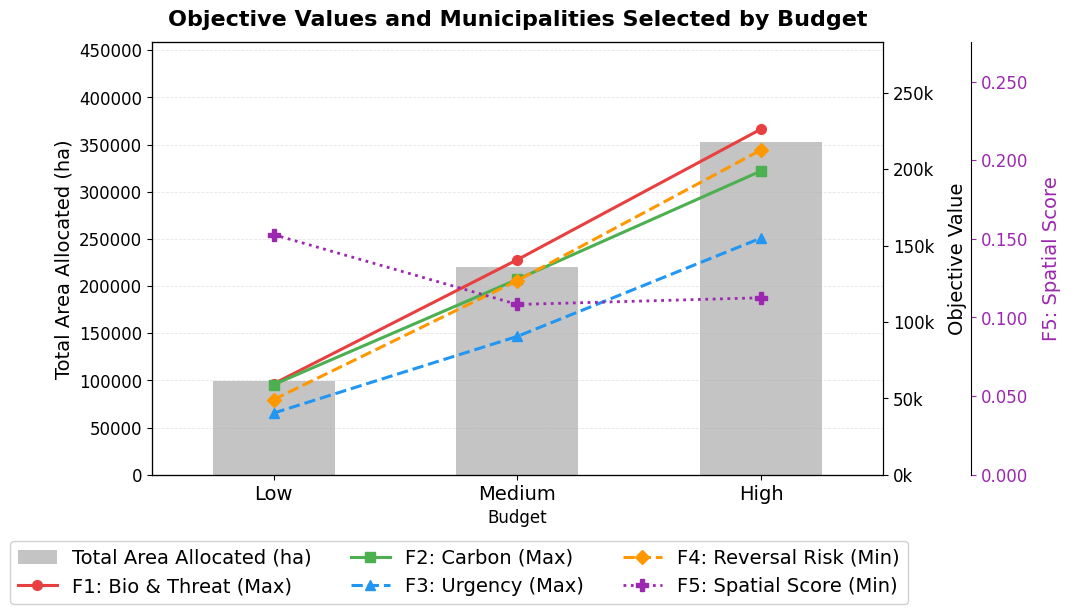

In [31]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

# --- Pull plotting data directly from joint_objectives_df ---
plot_df = joint_objectives_df.copy()

# Keep expected budget order if present
preferred_cols = ["Low Budget", "Medium Budget", "High Budget"]
budget_cols = [c for c in preferred_cols if c in plot_df.columns]
if not budget_cols:
    raise ValueError("No budget columns found in joint_objectives_df.")

# Ensure numeric dtype
for c in budget_cols:
    plot_df[c] = pd.to_numeric(plot_df[c], errors="coerce")

budget_labels = [c.replace(" Budget", "") for c in budget_cols]
x = np.arange(len(budget_labels))
bar_width = 0.5

# Row labels expected in joint_objectives_df
row_bar = "Total Area Allocated (ha)"
objective_rows = [
    "F1: Bio & Threat (Max)",
    "F2: Carbon (Max)",
    "F3: Urgency (Max)",
    "F4: Reversal Risk (Min)",
    "F5: Spatial Score (Min)",
]

# Validate required rows exist
missing_rows = [r for r in [row_bar, *objective_rows] if r not in plot_df.index]
if missing_rows:
    raise ValueError(f"Missing required rows in joint_objectives_df: {missing_rows}")

# Bars + objective data
bar_values = plot_df.loc[row_bar, budget_cols].tolist()
objectives = {r: plot_df.loc[r, budget_cols].tolist() for r in objective_rows}

# F5 on separate axis
line_objs = {k: v for k, v in objectives.items() if k != "F5: Spatial Score (Min)"}
f5_vals = objectives["F5: Spatial Score (Min)"]

line_colors = ["#E84040", "#4CAF50", "#2196F3", "#FF9800"]
line_styles = ["-", "-", "--", "--"]
markers = ["o", "s", "^", "D"]

# --- Figure & axes ---
fig, ax_bar = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("white")
ax_bar.set_facecolor("white")

ax_obj = ax_bar.twinx()
ax_f5 = ax_bar.twinx()
ax_f5.spines["right"].set_position(("axes", 1.12))

# --- Bars: Number of Municipalities Selected ---
ax_bar.bar(
    x, bar_values, width=bar_width,
    color="#B0B0B0", alpha=0.75, zorder=2,
    label="Total Area Allocated (ha)"
)

# --- Lines: F1-F4 ---
for (name, vals), color, ls, mk in zip(line_objs.items(), line_colors, line_styles, markers):
    ax_obj.plot(
        x, vals, color=color, linestyle=ls, linewidth=2.2,
        marker=mk, markersize=7, zorder=3, label=name
    )

# --- Line: F5 ---
ax_f5.plot(
    x, f5_vals, color="#9C27B0", linestyle=":", linewidth=2,
    marker="P", markersize=8, zorder=3, label="F5: Spatial Score (Min)"
)
ax_f5.set_ylabel("F5: Spatial Score", fontsize=14, color="#9C27B0", labelpad=10)
ax_f5.tick_params(axis="y", colors="#9C27B0", labelsize=12)
ax_f5.set_ylim(0, max(f5_vals) * 1.8 if max(f5_vals) > 0 else 1)
ax_f5.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))

# --- Axis formatting ---
ax_bar.set_xlabel("Budget", fontsize=12)
ax_bar.set_ylabel("Total Area Allocated (ha)", fontsize=14)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(budget_labels, fontsize=14)
ax_bar.set_ylim(0, max(bar_values) * 1.3 if max(bar_values) > 0 else 1)
ax_bar.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax_bar.tick_params(axis="y", labelsize=12)

ax_obj.set_ylabel("Objective Value", fontsize=14, labelpad=10)
max_obj = max(max(v) for v in line_objs.values()) if line_objs else 1
ax_obj.set_ylim(0, max_obj * 1.25)
ax_obj.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
ax_obj.tick_params(axis="y", labelsize=12)

ax_bar.set_xlim(-0.5, len(budget_labels) - 0.5)
ax_bar.yaxis.grid(True, linestyle="--", linewidth=0.6, alpha=0.5, color="#CCCCCC")
ax_bar.set_axisbelow(True)

ax_bar.set_title("Objective Values and Municipalities Selected by Budget", fontsize=16, fontweight="bold", pad=12)

# --- Combined legend ---
handles, labels = [], []
h, l = ax_bar.get_legend_handles_labels(); handles += h; labels += l
h, l = ax_obj.get_legend_handles_labels(); handles += h; labels += l
h, l = ax_f5.get_legend_handles_labels(); handles += h; labels += l

ax_bar.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.42, -0.13),
    ncol=3, fontsize=14,
    frameon=True, framealpha=0.9,
    edgecolor="#CCCCCC"
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.2, right=0.87)
plt.savefig("Figures/Budget Sensitivity Analysis/Budget_Sensitivity_Analysis.png", dpi=300, bbox_inches='tight')
plt.show()

In [34]:
# sort selected_df_budget_low by cost in descending order
selected_df_budget_low_sorted = selected_df_budget_low.sort_values(by="Cost", ascending=False)
selected_df_budget_medium_sorted = selected_df_budget_medium.sort_values(by="Cost", ascending=False)
selected_df_budget_high_sorted = selected_df_budget_high.sort_values(by="Cost", ascending=False)

selected_df_budget_low_sorted.to_csv("Outputs/Para Allocations/Selected_Municipalities_Low_Budget.csv", index=False)
selected_df_budget_medium_sorted.to_csv("Outputs/Para Allocations/Selected_Municipalities_Medium_Budget.csv", index=False)
selected_df_budget_high_sorted.to_csv("Outputs/Para Allocations/Selected_Municipalities_High_Budget.csv", index=False)

## Para Allocation Plot (Side by Side)

In [41]:
import matplotlib.pyplot as plt
import geopandas as gpd
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np
from pathlib import Path 



def budget_allocation_para_municipality_graphic(alloc_df, obj_name, all_municipalities):
    allocation = alloc_df.copy()

    allocation = allocation.merge(
        df[['NM_MUN', 'CD_MUN']],
        left_on='Municipality',
        right_on='NM_MUN',
        how='left'
    )

    # list of municipalities in para
    para_municipalities = municipalities_gdf[municipalities_gdf['NM_UF'] == "Pará"]

    para_municipalities['CD_MUN'] = para_municipalities['CD_MUN'].astype(int)

    # merge the geodataframe with allocation datagrame to get the geometry for each municipality
    para_alloc = para_municipalities.merge(
        allocation,
        left_on='CD_MUN',
        right_on='CD_MUN',
        how='left'
    )
    # check how many municipalities have missing allocations (i.e., not selected in the optimal solution)
    print(para_alloc["Cost"].isna().sum(), "municipalities missing allocations")
    print(len(para_alloc), "total municipalities")

    return para_alloc
def plot_budget_allocation_map(para_alloc, obj_name):
    import matplotlib.ticker as mticker

    para_municipalities = municipalities_gdf[municipalities_gdf["NM_UF"] == "Pará"]
    funded = para_alloc[para_alloc["Cost"].notna() & (para_alloc["Cost"] > 0)].copy()

    if funded.empty:
        print("No funded municipalities found (Cost > 0).")
        return

    vmin = funded["Cost"].min()
    vmax = funded["Cost"].max()

    fig = plt.figure(figsize=(12, 12))
    ax_map = fig.add_axes([0.05, 0.08, 0.85, 0.84])

    para_municipalities.plot(
        ax=ax_map, color="#e8e8e8", edgecolor="#aaaaaa", linewidth=0.3
    )

    funded.plot(
        ax=ax_map,
        column="Cost",
        cmap="YlGn",
        edgecolor="#333333",
        linewidth=0.6,
        vmin=vmin,
        vmax=vmax,
        legend=False
    )

    sm = plt.cm.ScalarMappable(cmap="YlGn", norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax_map, orientation="vertical", fraction=0.03, pad=0.02)
    cbar.set_label("Reforestation Budget (USD)", fontsize=16)
    cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    cbar.ax.tick_params(labelsize=14)

    ax_map.annotate(
        "N", xy=(0.96, 0.95), xycoords="axes fraction",
        ha="center", va="bottom", fontsize=16, fontweight="bold"
    )
    ax_map.annotate(
        "▲", xy=(0.96, 0.92), xycoords="axes fraction",
        ha="center", va="top", fontsize=18
    )

    ax_map.set_title(
        f"Reforestation Budget Allocation Across Pará Municipalities\nObjective: {obj_name}",
        fontsize=18, fontweight="bold", pad=12
    )
    ax_map.set_axis_off()


    # saving the figure to /Figures folder which is a subfolder of the current working directory
    out_dir = Path("Figures/Para Allocation Plots")
    filename = f"Para_Budget_Map_{obj_name.replace(' ', '_')}.png"
    out_path = out_dir / filename
    #plt.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

def plot_budget_allocation_map_side_by_side(para_alloc_1, obj_name_1, para_alloc_2, obj_name_2):
    """Plot two budget allocation maps side by side with a single colorbar on the right."""
    import matplotlib.ticker as mticker
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    
    para_municipalities = municipalities_gdf[municipalities_gdf["NM_UF"] == "Pará"]
    funded_1 = para_alloc_1[para_alloc_1["Cost"].notna() & (para_alloc_1["Cost"] > 0)].copy()
    funded_2 = para_alloc_2[para_alloc_2["Cost"].notna() & (para_alloc_2["Cost"] > 0)].copy()
    
    if funded_1.empty or funded_2.empty:
        print("One or both datasets have no funded municipalities (Cost > 0).")
        return
    
    # Use the same scale for both maps
    vmin = min(funded_1["Cost"].min(), funded_2["Cost"].min())
    vmax = max(funded_1["Cost"].max(), funded_2["Cost"].max())
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 12))
    
    # Plot first map
    para_municipalities.plot(
        ax=ax1, color="#e8e8e8", edgecolor="#aaaaaa", linewidth=0.3
    )
    funded_1.plot(
        ax=ax1,
        column="Cost",
        cmap="YlGn",
        edgecolor="#333333",
        linewidth=0.6,
        vmin=vmin,
        vmax=vmax,
        legend=False
    )
    #ax1.annotate(
    #    "N", xy=(0.96, 0.95), xycoords="axes fraction",
    #    ha="center", va="bottom", fontsize=16, fontweight="bold"
    #)
    #ax1.annotate(
    #    "▲", xy=(0.96, 0.92), xycoords="axes fraction",
    #    ha="center", va="top", fontsize=18
    #)
    #ax1.set_title(
    #    f"Reforestation Budget Allocation\nObjective: {obj_name_1}",
    #    fontsize=16, fontweight="bold", pad=12
    #)
    ax1.set_axis_off()
    
    # Plot second map
    para_municipalities.plot(
        ax=ax2, color="#e8e8e8", edgecolor="#aaaaaa", linewidth=0.3
    )
    funded_2.plot(
        ax=ax2,
        column="Cost",
        cmap="YlGn",
        edgecolor="#333333",
        linewidth=0.6,
        vmin=vmin,
        vmax=vmax,
        legend=False
    )
    ax2.annotate(
        "N", xy=(0.96, 0.95), xycoords="axes fraction",
        ha="center", va="bottom", fontsize=16, fontweight="bold"
    )
    ax2.annotate(
        "▲", xy=(0.96, 0.92), xycoords="axes fraction",
        ha="center", va="top", fontsize=18
    )
    #ax2.set_title(
    #    f"Reforestation Budget Allocation\nObjective: {obj_name_2}",
    #    fontsize=18, fontweight="bold", pad=12
    #)
    ax2.set_axis_off()
    
    # Add single colorbar on the right
    sm = plt.cm.ScalarMappable(cmap="YlGn", norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    #cbar.set_label("Reforestation Budget (USD)", fontsize=22)
    cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.0f} mil"))
    cbar.ax.tick_params(labelsize=18)
    
    plt.suptitle("Comparison of Reforestation Budget Allocations Across Pará Municipalities", 
                 fontsize=26, fontweight="bold", y=0.98)
    
    # saving the figure to /Figures folder which is a subfolder of the current working directory
    out_dir = Path("Figures/Para Allocation Plots")
    filename = f"Para_Budget_Map_{obj_name_1.replace(' ', '_')}_vs_{obj_name_2.replace(' ', '_')}.png"
    out_path = out_dir / filename
    plt.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

c:\Users\alasd\AppData\Local\Programs\Python\Python310\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\alasd\AppData\Local\Programs\Python\Python310\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


119 municipalities missing allocations
144 total municipalities
119 municipalities missing allocations
144 total municipalities


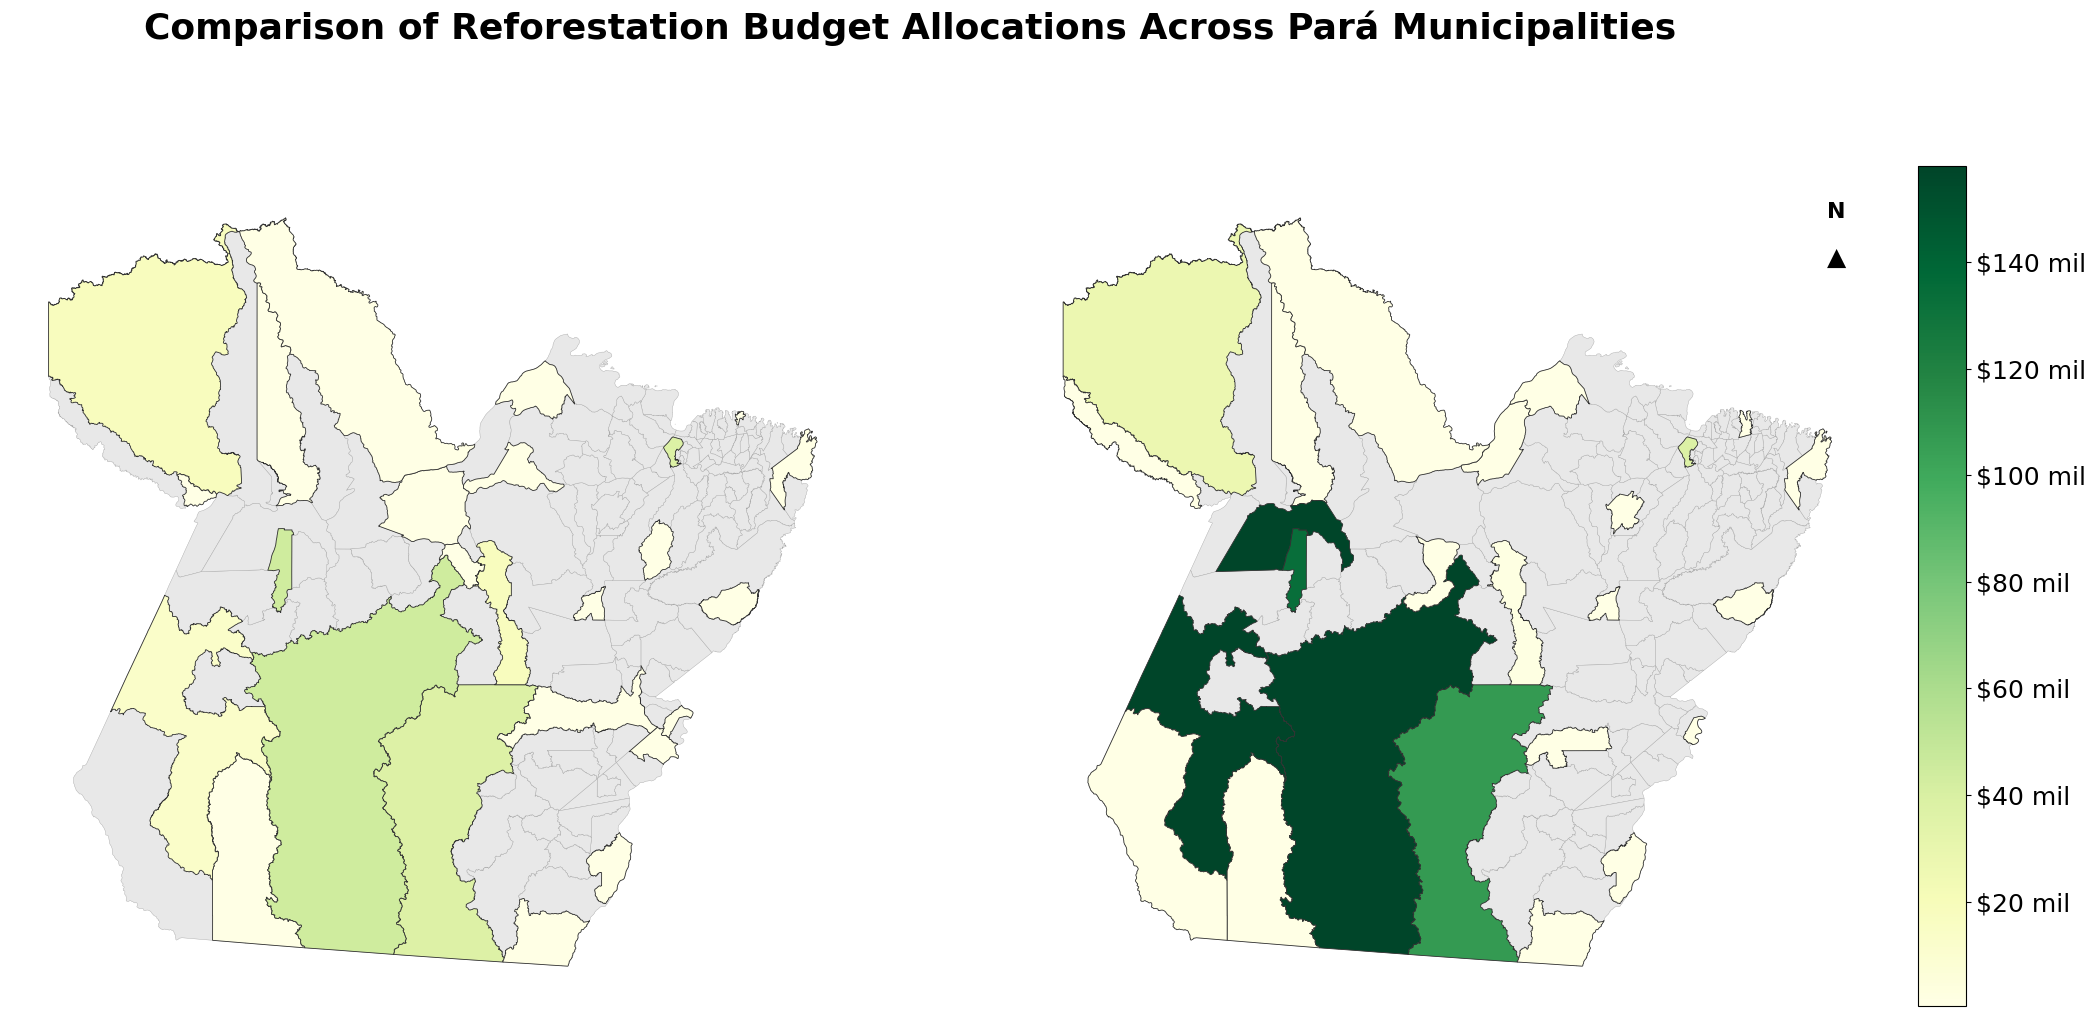

In [42]:
para_alloc_1 = budget_allocation_para_municipality_graphic(selected_df_budget_high_sorted, 'Low Budget Allocation', municipalities_gdf)
para_alloc_2 = budget_allocation_para_municipality_graphic(selected_df_budget_low_sorted, 'High Budget Allocation', municipalities_gdf)

plot_budget_allocation_map_side_by_side(para_alloc_2, 'High Budget Allocation', para_alloc_1, 'Low Budget Allocation')